In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score

from xgboost import XGBRegressor, plot_importance
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/ML solarcell dataset/concatenated_all_final.xlsx')

df.head(5)

Mounted at /content/drive


,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Nv,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure
0,0.1,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971704,37.583326,87.4922,31.9520,Structure_1
1,0.2,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971972,37.923123,87.5007,32.2529,Structure_1
2,0.3,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972158,38.144859,87.4986,32.4469,Structure_1
3,0.4,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972395,38.294786,87.3901,32.5420,Structure_1
4,0.5,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972767,38.399561,87.0872,32.5304,Structure_1


In [3]:
df

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Nv,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure
0,0.1,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971704,37.583326,87.4922,31.9520,Structure_1
1,0.2,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971972,37.923123,87.5007,32.2529,Structure_1
2,0.3,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972158,38.144859,87.4986,32.4469,Structure_1
3,0.4,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972395,38.294786,87.3901,32.5420,Structure_1
4,0.5,1.50,4.50,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972767,38.399561,87.0872,32.5304,Structure_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16785,15.0,1.12,4.05,11.9,1.000000e+19,1.000000e+19,1350.0,500.0,1.000000e+16,100000000000,...,1.000000e+18,3000,20,5.000000e+19,100000000000000,1.033562,43.550977,83.3367,37.5121,Structure_24
16786,15.0,1.12,4.05,11.9,1.000000e+19,1.000000e+19,1350.0,500.0,1.000000e+16,100000000000,...,1.000000e+19,3000,20,5.000000e+19,100000000000000,1.004519,43.550975,84.9360,37.1576,Structure_24
16787,15.0,1.12,4.05,11.9,1.000000e+19,1.000000e+19,1350.0,500.0,1.000000e+16,100000000000,...,1.000000e+17,3000,20,5.000000e+19,100000000000000,1.003279,43.550977,84.9916,37.1360,Structure_24
16788,15.0,1.12,4.05,11.9,1.000000e+19,1.000000e+19,1350.0,500.0,1.000000e+16,100000000000,...,1.000000e+18,3000,20,5.000000e+19,100000000000000,0.988246,43.550976,85.6034,36.8429,Structure_24


In [4]:
from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df['Structure'] = le.fit_transform(df['Structure'])

# Replace 'Structure_x' with just x
df["Structure"] = df["Structure"].str.replace("Structure_", "").astype(int)

In [5]:
df.describe()

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Nv,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure
count,16790.000000,16790.000000,16790.000000,16790.000000,1.679000e+04,1.679000e+04,16790.000000,16790.000000,1.679000e+04,1.679000e+04,...,1.679000e+04,16790.000000,16790.000000,1.679000e+04,1.679000e+04,16790.000000,16790.000000,16790.000000,16790.000000,16790.000000
mean,3.007433,1.401331,4.262519,12.645408,5.655086e+18,1.736610e+19,330.229801,110.002824,8.381587e+17,1.033385e+14,...,6.507172e+18,1018.513401,25.298035,4.319529e+19,1.193201e+14,0.994534,37.207171,82.330058,30.274492,12.357594
std,5.261317,0.175999,0.192034,2.773158,1.019237e+19,2.494934e+19,456.961158,171.066425,5.584472e+18,3.850195e+14,...,7.802841e+18,1202.437309,5.517113,6.022537e+19,3.824673e+14,0.143752,7.213629,6.459050,6.761151,6.842070
min,0.100000,0.900000,3.800000,1.000000,5.000000e+15,5.000000e+15,10.000000,1.000000,1.000000e+14,1.000000e+11,...,5.000000e+15,10.000000,1.000000,1.000000e+15,1.000000e+12,0.476734,0.005364,22.475700,0.005200,1.000000
25%,0.700000,1.200000,4.100000,10.500000,1.180000e+18,4.570000e+18,100.000000,25.000000,1.000000e+16,1.000000e+14,...,1.610000e+18,100.000000,20.000000,1.000000e+18,1.000000e+14,0.911674,34.735479,79.623800,25.892425,6.000000
50%,0.700000,1.500000,4.280000,12.500000,1.200000e+18,5.200000e+18,130.000000,50.000000,1.000000e+16,1.000000e+14,...,1.800000e+18,700.000000,25.000000,5.000000e+19,1.000000e+14,0.999238,38.514235,83.437550,31.571900,12.000000
75%,0.800000,1.500000,4.400000,14.800000,2.200000e+18,1.800000e+19,320.000000,56.700000,1.000000e+16,1.000000e+14,...,1.000000e+19,3000.000000,30.000000,5.000000e+19,1.000000e+14,1.097389,41.675635,86.670900,35.865650,18.000000
max,19.000000,2.350000,5.200000,45.000000,1.000000e+20,1.000000e+20,1350.000000,500.000000,5.000000e+19,1.000000e+16,...,1.000000e+20,3000.000000,90.000000,5.000000e+20,1.000000e+16,1.539987,57.958243,91.135200,43.931400,24.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16790 entries, 0 to 16789
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   L1 Thickness  16790 non-null  float64
 1   L1 Bg         16790 non-null  float64
 2   L1 Ea         16790 non-null  float64
 3   L1 Dp         16790 non-null  float64
 4   L1 Nc         16790 non-null  float64
 5   L1 Nv         16790 non-null  float64
 6   L1 Ue         16790 non-null  float64
 7   L1 Uh         16790 non-null  float64
 8   L1 Na         16790 non-null  float64
 9   L1 dd         16790 non-null  int64  
 10  L2 Thickness  16790 non-null  float64
 11  L2 Bg         16790 non-null  float64
 12  L2 Ea         16790 non-null  float64
 13  L2 Dp         16790 non-null  float64
 14  L2 Nc         16790 non-null  float64
 15  L2 Nv         16790 non-null  float64
 16  L2 Ue         16790 non-null  int64  
 17  L2 Uh         16790 non-null  int64  
 18  L2 Na         16790 non-nu

In [7]:
for col in df.columns:
  if col != 'Structure':
    df[col] = df[col].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16790 entries, 0 to 16789
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   L1 Thickness  16790 non-null  float64
 1   L1 Bg         16790 non-null  float64
 2   L1 Ea         16790 non-null  float64
 3   L1 Dp         16790 non-null  float64
 4   L1 Nc         16790 non-null  float64
 5   L1 Nv         16790 non-null  float64
 6   L1 Ue         16790 non-null  float64
 7   L1 Uh         16790 non-null  float64
 8   L1 Na         16790 non-null  float64
 9   L1 dd         16790 non-null  float64
 10  L2 Thickness  16790 non-null  float64
 11  L2 Bg         16790 non-null  float64
 12  L2 Ea         16790 non-null  float64
 13  L2 Dp         16790 non-null  float64
 14  L2 Nc         16790 non-null  float64
 15  L2 Nv         16790 non-null  float64
 16  L2 Ue         16790 non-null  float64
 17  L2 Uh         16790 non-null  float64
 18  L2 Na         16790 non-nu

In [8]:
# Finding max value
max = df.PCE.max()
max

43.9314

In [9]:
df['FF'] = df['FF'] / 100

In [ ]:
# df[df["FF"] < .50]

In [ ]:
# df = df[df["FF"] >= .50]

In [ ]:
# df = df[df.PCE != 0]

In [10]:
bsf_map = {
    1: 'MoS2', 2: 'MoS2', 3: 'WSe2', 4: 'MoS2', 5: 'WSe2', 6: 'MoS2', 7: 'CGS', 8: 'MoS2',
    9: 'WSe2', 10: 'MoS2', 11: 'CGS', 12: 'WSe2', 13: 'MoS2', 14: 'MoS2', 15: 'CGS',
    16: 'WSe2', 17: 'WSe2', 18: 'MoS2', 19: 'CGS', 20: 'WSe2', 21: 'WSe2',
    22: 'WSe2', 23: 'CGS', 24: 'WSe2',
}

# Create new column using map
df["BSF"] = df["Structure"].map(bsf_map)

bsf_map = {
    'MoS2': 1,
    'WSe2': 2,
    'CGS': 3,
}

# Create new column using map
df["BSF"] = df["BSF"].map(bsf_map)

df['L1 Bg + L1 Ea'] = df['L1 Bg'] + df['L1 Ea']
df['L2 Bg + L2 Ea'] = df['L2 Bg'] + df['L2 Ea']

df['CB offset'] = df['L1 Ea'] - df['L2 Ea']
df['VB offset'] = df['L1 Bg + L1 Ea'] - df['L2 Bg + L2 Ea']

df.drop(columns=["L1 Bg + L1 Ea", "L2 Bg + L2 Ea"], inplace=True)

In [11]:
df.head()

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure,BSF,CB offset,VB offset
0,0.1,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.971704,37.583326,0.874922,31.9520,1,1,0.2,0.6
1,0.2,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.971972,37.923123,0.875007,32.2529,1,1,0.2,0.6
2,0.3,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.972158,38.144859,0.874986,32.4469,1,1,0.2,0.6
3,0.4,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.972395,38.294786,0.873901,32.5420,1,1,0.2,0.6
4,0.5,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.972767,38.399561,0.870872,32.5304,1,1,0.2,0.6


In [12]:
df = df.rename(columns={'L1 Thickness': 'L1\nThickness'})
df = df.rename(columns={'L2 Thickness': 'L2\nThickness'})

In [13]:
df.head()

,L1\nThickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure,BSF,CB offset,VB offset
0,0.1,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.971704,37.583326,0.874922,31.9520,1,1,0.2,0.6
1,0.2,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.971972,37.923123,0.875007,32.2529,1,1,0.2,0.6
2,0.3,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.972158,38.144859,0.874986,32.4469,1,1,0.2,0.6
3,0.4,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.972395,38.294786,0.873901,32.5420,1,1,0.2,0.6
4,0.5,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,5.000000e+19,1.000000e+14,0.972767,38.399561,0.870872,32.5304,1,1,0.2,0.6


# <font color="lightgreen"> **Correlation Heat map for 1st and 2nd layer**

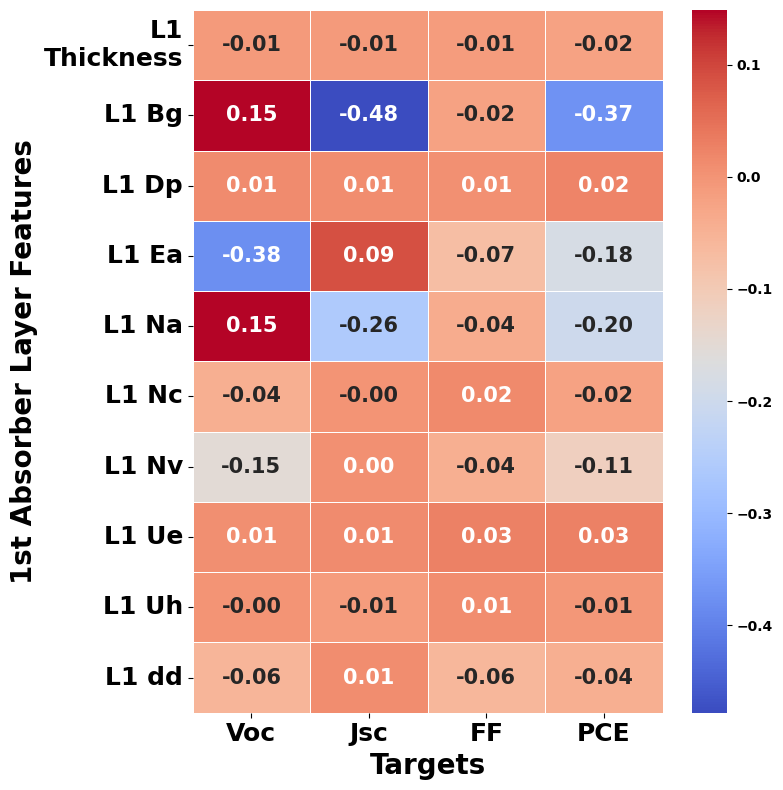

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define your feature and target groups
l1_features = ['L1\nThickness', 'L1 Bg', 'L1 Ea', 'L1 Dp', 'L1 Nc', 'L1 Nv',
               'L1 Ue', 'L1 Uh', 'L1 Na', 'L1 dd']
targets = ['Voc', 'Jsc', 'FF', 'PCE']

# Initialize a list to store correlations for each structure
corr_list = []

# Loop over each unique structure
for struct in df['Structure'].unique():
    df_struct = df[df['Structure'] == struct]
    corr = df_struct[l1_features + targets].corr().loc[l1_features, targets]
    corr_list.append(corr)

# Average correlation across all structures
avg_corr_l1 = pd.concat(corr_list).groupby(level=0).mean()

# Plot heatmap
plt.figure(figsize=(8, 8))
ax = sns.heatmap(avg_corr_l1, annot=True, fmt=".2f", cmap='coolwarm', linewidths= 0.5,
            xticklabels=True, yticklabels=True,
            annot_kws={"fontweight": "bold", "fontsize": 15}
            )
# Increase colorbar tick labels
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")

# plt.title("Average Correlation: Targets vs L1 Features (Across 24 Structures)", fontsize=16)
plt.xticks(rotation=0, fontsize=18, fontweight = 'bold')
plt.yticks(rotation=0, fontsize=18, fontweight = 'bold')
plt.xlabel("Targets", fontsize=20, fontweight = 'bold')
plt.ylabel("1st Absorber Layer Features", fontsize=20, fontweight = 'bold')
plt.tight_layout()
plt.savefig("correlation_L1.png", dpi=600, bbox_inches='tight')
plt.show()


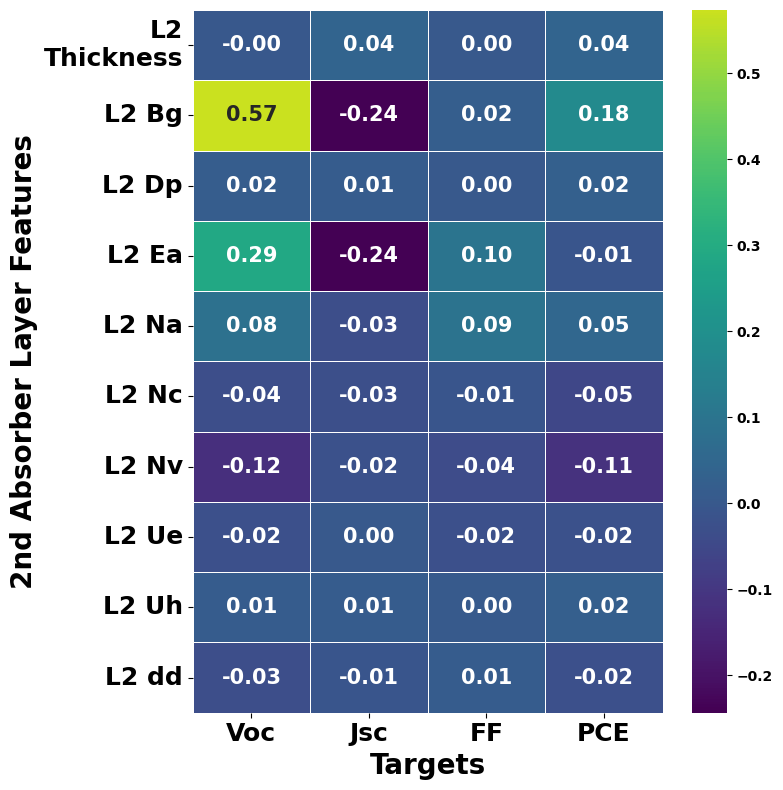

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define your feature and target groups
l2_features = ['L2\nThickness', 'L2 Bg', 'L2 Ea', 'L2 Dp', 'L2 Nc', 'L2 Nv',
               'L2 Ue', 'L2 Uh', 'L2 Na', 'L2 dd']
targets = ['Voc', 'Jsc', 'FF', 'PCE']

# Initialize a list to store correlations for each structure
corr_list_2 = []

# Loop over each unique structure
for struct in df['Structure'].unique():
    df_struct = df[df['Structure'] == struct]
    corr = df_struct[l2_features + targets].corr().loc[l2_features, targets]
    corr_list_2.append(corr)

# Average correlation across all structures
avg_corr_l2 = pd.concat(corr_list_2).groupby(level=0).mean()

# Plot heatmap
plt.figure(figsize=(8, 8))
ax = sns.heatmap(avg_corr_l2, annot=True, fmt=".2f", cmap='viridis', linewidths= 0.5, center = 0.2,
            xticklabels=True, yticklabels=True,
            annot_kws={"fontweight": "bold", "fontsize": 15}
            )

# Increase colorbar tick labels
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")

# plt.title("Average Correlation: Targets vs L2 Features (Across 24 Structures)", fontsize=16, fontweight = 'bold')
plt.xticks(rotation=0, fontsize=18, fontweight = 'bold')
plt.yticks(rotation=0, fontsize=18, fontweight = 'bold')
plt.xlabel("Targets", fontsize=20, fontweight = 'bold')
plt.ylabel("2nd Absorber Layer Features", fontsize=20, fontweight = 'bold')
plt.tight_layout()
plt.savefig("correlation_L2.png", dpi=600, bbox_inches='tight')
plt.show()

